*Copyright (c) Recommenders contributors.*

*Licensed under the MIT License.*

# Wide and Deep Model for Movie Recommendation (PyTorch)

<br>

A linear model with a wide set of crossed-column (co-occurrence) features can memorize the feature interactions, while deep neural networks (DNN) can generalize the feature patterns through low-dimensional dense embeddings learned for the sparse features. [**Wide and Deep**](https://arxiv.org/abs/1606.07792) learning jointly trains wide linear model and deep neural networks to combine the benefits of memorization and generalization for recommender systems.

This notebook shows how to build and test the wide-and-deep model using PyTorch. With the [movie recommendation dataset](https://grouplens.org/datasets/movielens/), we quickly demonstrate following topics:
1. How to prepare data
2. Build the model
3. Train with periodic evaluation
4. Test the model and export

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import sys
import math
import logging
import sklearn
import pandas as pd
import torch

from recommenders.utils.constants import (
    DEFAULT_USER_COL as USER_COL,
    DEFAULT_ITEM_COL as ITEM_COL,
    DEFAULT_RATING_COL as RATING_COL,
    DEFAULT_PREDICTION_COL as PREDICT_COL,
    DEFAULT_GENRE_COL as ITEM_FEAT_COL,
    SEED
)
from recommenders.utils import plot
from recommenders.datasets import movielens
from recommenders.datasets.pandas_df_utils import user_item_pairs
from recommenders.datasets.python_splitters import python_random_split
import recommenders.evaluation.python_evaluation as evaluator
from recommenders.models.wide_deep.wide_deep_utils import (
    build_feature_columns,
    build_model,
    train_model,
    predict,
)
from recommenders.utils.notebook_utils import store_metadata

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

print(f"System version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

System version: 3.11.14 (main, Jan 14 2026, 19:35:32) [Clang 21.1.4 ]
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5090 Laptop GPU


In [3]:
# Parameters

# Recommend top k items
TOP_K = 10
# Select MovieLens data size: 100k, 1m, 10m, or 20m
MOVIELENS_DATA_SIZE = "100k"
# Metrics to use for evaluation
RANKING_METRICS = [evaluator.ndcg_at_k.__name__, evaluator.precision_at_k.__name__]
RATING_METRICS = [evaluator.rmse.__name__, evaluator.mae.__name__]
# Use periodic evaluation during training
EVALUATE_WHILE_TRAINING = True

RANDOM_SEED = SEED  # Set seed for deterministic result

# Train and test set pickle file paths. If provided, use them. Otherwise, download the MovieLens dataset.
DATA_DIR = None
TRAIN_PICKLE_PATH = None
TEST_PICKLE_PATH = None
EXPORT_DIR_BASE = os.path.join("outputs", "model")

#### Hyperparameters
MODEL_TYPE = "wide_deep"
STEPS = 50000  # Number of batches to train
BATCH_SIZE = 32
# Wide (linear) model hyperparameters
LINEAR_OPTIMIZER = "adagrad"
LINEAR_OPTIMIZER_LR = 0.0621  # Learning rate
# DNN model hyperparameters
DNN_OPTIMIZER = "adadelta"
DNN_OPTIMIZER_LR = 0.1
# Layer dimensions. Set 0 to skip a layer.
DNN_HIDDEN_LAYER_1 = 0
DNN_HIDDEN_LAYER_2 = 64
DNN_HIDDEN_LAYER_3 = 128
DNN_HIDDEN_LAYER_4 = 512
DNN_HIDDEN_UNITS = [h for h in [DNN_HIDDEN_LAYER_1, DNN_HIDDEN_LAYER_2, DNN_HIDDEN_LAYER_3, DNN_HIDDEN_LAYER_4] if h > 0]
DNN_USER_DIM = 32          # User embedding feature dimension
DNN_ITEM_DIM = 16          # Item embedding feature dimension
DNN_DROPOUT = 0.8
DNN_BATCH_NORM = 1         # 1 to use batch normalization, 0 if not.

### 1. Prepare Data

#### 1.1 Movie Rating and Genres Data
First, download [MovieLens](https://grouplens.org/datasets/movielens/) data. Movies in the data set are tagged as one or more genres where there are total 19 genres including '*unknown*'. We load *movie genres* to use them as item features.

In [4]:
use_preset = (TRAIN_PICKLE_PATH is not None and TEST_PICKLE_PATH is not None)
if not use_preset:
    # The genres of each movie are returned as '|' separated string, e.g. "Animation|Children's|Comedy".
    data = movielens.load_pandas_df(
        size=MOVIELENS_DATA_SIZE,
        header=[USER_COL, ITEM_COL, RATING_COL],
        genres_col=ITEM_FEAT_COL
    )
    display(data.head())

INFO:recommenders.datasets.download_utils:Downloading http://files.grouplens.org/datasets/movielens/ml-100k.zip
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.81k/4.81k [00:01<00:00, 2.63kKB/s]


,userID,itemID,rating,genre
0,196,242,3.0,Comedy
1,186,302,3.0,Crime|Film-Noir|Mystery|Thriller
2,22,377,1.0,Children's|Comedy
3,244,51,2.0,Drama|Romance|War|Western
4,166,346,1.0,Crime|Drama


#### 1.2 Encode Item Features (Genres)
To use genres from our model, we multi-hot-encode them with scikit-learn's [MultiLabelBinarizer](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MultiLabelBinarizer.html).

For example, *Movie id=2355* has three genres, *Animation|Children's|Comedy*, which are being converted into an integer array of the indicator value for each genre like `[0, 0, 1, 1, 1, 0, 0, 0, ...]`. In the later step, we convert this into a float array and feed into the model.

> For faster feature encoding, you may load ratings and items separately (by using `movielens.load_item_df`), encode the item-features, then combine the rating and item dataframes by using join-operation.

In [5]:
if not use_preset and ITEM_FEAT_COL is not None:
    # Encode 'genres' into int array (multi-hot representation) to use as item features
    genres_encoder = sklearn.preprocessing.MultiLabelBinarizer()
    data[ITEM_FEAT_COL] = genres_encoder.fit_transform(
        data[ITEM_FEAT_COL].apply(lambda s: s.split("|"))
    ).tolist()
    print("Genres:", genres_encoder.classes_)
    display(data.head())

Genres: ['Action' 'Adventure' 'Animation' "Children's" 'Comedy' 'Crime'
 'Documentary' 'Drama' 'Fantasy' 'Film-Noir' 'Horror' 'Musical' 'Mystery'
 'Romance' 'Sci-Fi' 'Thriller' 'War' 'Western' 'unknown']


,userID,itemID,rating,genre
0,196,242,3.0,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,186,302,3.0,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, ..."
2,22,377,1.0,"[0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,244,51,2.0,"[0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, ..."
4,166,346,1.0,"[0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, ..."


#### 1.3 Train and Test Split

In [6]:
if not use_preset:
    train, test = python_random_split(data, ratio=0.75, seed=RANDOM_SEED)
else:
    train = pd.read_pickle(path=TRAIN_PICKLE_PATH if DATA_DIR is None else os.path.join(DATA_DIR, TRAIN_PICKLE_PATH))
    test = pd.read_pickle(path=TEST_PICKLE_PATH if DATA_DIR is None else os.path.join(DATA_DIR, TEST_PICKLE_PATH))
    data = pd.concat([train, test])

print("{} train samples and {} test samples".format(len(train), len(test)))

75000 train samples and 25000 test samples


In [7]:
# Unique items in the dataset
if ITEM_FEAT_COL is None:
    items = data.drop_duplicates(ITEM_COL)[[ITEM_COL]].reset_index(drop=True)
    item_feat_shape = None
else:
    items = data.drop_duplicates(ITEM_COL)[[ITEM_COL, ITEM_FEAT_COL]].reset_index(drop=True)
    item_feat_shape = len(items[ITEM_FEAT_COL][0])
# Unique users in the dataset
users = data.drop_duplicates(USER_COL)[[USER_COL]].reset_index(drop=True)

print("Total {} items and {} users in the dataset".format(len(items), len(users)))

Total 1682 items and 943 users in the dataset


### 2. Build Model

Wide-and-deep model consists of a linear model and DNN. We use the following hyperparameters and feature sets for the model:

<br> | <div align="center">Wide (linear) model</div> | <div align="center">Deep neural networks</div>
---|---|---
Feature set | <ul><li>User-item co-occurrence features<br>to capture how their co-occurrence<br>correlates with the target rating</li></ul> | <ul><li>Deep, lower-dimensional embedding vectors<br>for every user and item</li><li>Item feature vector</li></ul>
Hyperparameters | <ul><li>Adagrad optimizer</li><li>Learning rate = 0.0621</li></ul> | <ul><li>Adadelta optimizer</li><li>Learning rate = 0.1</li><li>Hidden units = [64, 128, 512]</li><li>Dropout rate = 0.8</li><li>Use batch normalization (Batch size = 32)</li><li>User embedding vector size = 32</li><li>Item embedding vector size = 16</li></ul>

In [8]:
# Define wide (linear) and deep (dnn) feature configurations
wide_columns, deep_columns = build_feature_columns(
    users=users[USER_COL].values,
    items=items[ITEM_COL].values,
    user_col=USER_COL,
    item_col=ITEM_COL,
    item_feat_col=ITEM_FEAT_COL,
    crossed_feat_dim=1000,
    user_dim=DNN_USER_DIM,
    item_dim=DNN_ITEM_DIM,
    item_feat_shape=item_feat_shape,
    model_type=MODEL_TYPE,
)

print("Wide columns:", {k: v for k, v in wide_columns.items() if k not in ('users', 'items')})
print("Deep columns:", {k: v for k, v in deep_columns.items() if k not in ('users', 'items')})

Wide columns: {'n_users': 943, 'n_items': 1682, 'user_col': 'userID', 'item_col': 'itemID', 'crossed_feat_dim': 1000}
Deep columns: {'n_users': 943, 'n_items': 1682, 'user_col': 'userID', 'item_col': 'itemID', 'user_dim': 32, 'item_dim': 16, 'item_feat_col': 'genre', 'item_feat_shape': 19}


In [9]:
# Build the model
model = build_model(
    wide_columns=wide_columns,
    deep_columns=deep_columns,
    dnn_hidden_units=DNN_HIDDEN_UNITS,
    dnn_dropout=DNN_DROPOUT,
    dnn_batch_norm=(DNN_BATCH_NORM == 1),
    seed=RANDOM_SEED,
)
print(model)

WideDeepModel(
  (wide_user): Embedding(943, 1)
  (wide_item): Embedding(1682, 1)
  (wide_cross): Embedding(1000, 1)
  (deep_user): Embedding(943, 32, max_norm=5.656854249492381)
  (deep_item): Embedding(1682, 16, max_norm=4.0)
  (dnn): Sequential(
    (0): Linear(in_features=67, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.8, inplace=False)
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.8, inplace=False)
    (8): Linear(in_features=128, out_features=512, bias=True)
    (9): ReLU()
    (10): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.8, inplace=False)
    (12): Linear(in_features=512, out_features=1, bias=True)
  )
)


### 3. Train and Evaluate Model

Now we are all set to train the model. Here, we show how to utilize an evaluation callback to track model performance while training. The callback estimates the model performance on the given data based on the specified evaluation functions. Note we pass the test set to evaluate the model on rating metrics while we use the ranking-pool (all user-item pairs) for ranking metrics.

> Note: The loss is Mean Squared Error. Square root of the loss is the same as [RMSE](https://en.wikipedia.org/wiki/Root-mean-square_deviation).

In [10]:
cols = {
    'col_user': USER_COL,
    'col_item': ITEM_COL,
    'col_rating': RATING_COL,
    'col_prediction': PREDICT_COL,
}

# Prepare ranking evaluation set, i.e. get the cross join of all user-item pairs
ranking_pool = user_item_pairs(
    user_df=users,
    item_df=items,
    user_col=USER_COL,
    item_col=ITEM_COL,
    user_item_filter_df=train,  # Remove seen items
    shuffle=True,
    seed=RANDOM_SEED
)

In [11]:
# Create checkpoint frequency
save_checkpoints_steps = max(1, STEPS // 5)

# Prepare evaluation logger
eval_log = {}

def evaluation_callback(m, step):
    """Evaluate the model on rating and ranking metrics."""
    # Rating metrics
    if len(RATING_METRICS) > 0:
        test_no_label = test.drop(RATING_COL, axis=1)
        preds = predict(
            m, test_no_label,
            users=wide_columns.get('users', deep_columns.get('users')),
            items=wide_columns.get('items', deep_columns.get('items')),
            item_feat_col=ITEM_FEAT_COL,
        )
        pred_df = test_no_label.copy()
        pred_df[PREDICT_COL] = preds
        for metric_name in RATING_METRICS:
            result = evaluator.metrics[metric_name](test, pred_df, **cols)
            eval_log.setdefault(metric_name, []).append(result)
            logger.info("Step %d - %s: %.4f", step, metric_name, result)

    # Ranking metrics
    if len(RANKING_METRICS) > 0:
        preds = predict(
            m, ranking_pool,
            users=wide_columns.get('users', deep_columns.get('users')),
            items=wide_columns.get('items', deep_columns.get('items')),
            item_feat_col=ITEM_FEAT_COL,
        )
        pred_df = ranking_pool.copy()
        pred_df[PREDICT_COL] = preds
        for metric_name in RANKING_METRICS:
            result = evaluator.metrics[metric_name](test, pred_df, **{**cols, 'k': TOP_K})
            eval_log.setdefault(metric_name, []).append(result)
            logger.info("Step %d - %s: %.4f", step, metric_name, result)

Let's train the model.

In [12]:
%%time
print(
    "Training steps = {}, Batch size = {} (num epochs ~ {})"
    .format(STEPS, BATCH_SIZE, (STEPS * BATCH_SIZE) // len(train))
)

model = train_model(
    model,
    train_df=train,
    users=wide_columns.get('users', deep_columns.get('users')),
    items=wide_columns.get('items', deep_columns.get('items')),
    y_col=RATING_COL,
    user_col=USER_COL,
    item_col=ITEM_COL,
    item_feat_col=ITEM_FEAT_COL,
    batch_size=BATCH_SIZE,
    steps=STEPS,
    wide_optimizer=LINEAR_OPTIMIZER,
    wide_optimizer_lr=LINEAR_OPTIMIZER_LR,
    deep_optimizer=DNN_OPTIMIZER,
    deep_optimizer_lr=DNN_OPTIMIZER_LR,
    seed=RANDOM_SEED,
    eval_fn=evaluation_callback if EVALUATE_WHILE_TRAINING else None,
    eval_every_n_steps=save_checkpoints_steps if EVALUATE_WHILE_TRAINING else None,
    log_every_n_steps=max(1, STEPS // 10),
)

Training steps = 50000, Batch size = 32 (num epochs ~ 21)


INFO:recommenders.models.wide_deep.wide_deep_utils:Step 5000/50000 – loss = 0.9416
INFO:recommenders.models.wide_deep.wide_deep_utils:Step 10000/50000 – loss = 1.3515
INFO:root:Step 10000 - rmse: 0.9622
INFO:root:Step 10000 - mae: 0.7676
INFO:root:Step 10000 - ndcg_at_k: 0.1516
INFO:root:Step 10000 - precision_at_k: 0.1355
INFO:recommenders.models.wide_deep.wide_deep_utils:Step 15000/50000 – loss = 0.7956
INFO:recommenders.models.wide_deep.wide_deep_utils:Step 20000/50000 – loss = 0.3298
INFO:root:Step 20000 - rmse: 0.9515
INFO:root:Step 20000 - mae: 0.7546
INFO:root:Step 20000 - ndcg_at_k: 0.1204
INFO:root:Step 20000 - precision_at_k: 0.1153
INFO:recommenders.models.wide_deep.wide_deep_utils:Step 25000/50000 – loss = 0.9862
INFO:recommenders.models.wide_deep.wide_deep_utils:Step 30000/50000 – loss = 0.9754
INFO:root:Step 30000 - rmse: 0.9497
INFO:root:Step 30000 - mae: 0.7541
INFO:root:Step 30000 - ndcg_at_k: 0.1050
INFO:root:Step 30000 - precision_at_k: 0.1018
INFO:recommenders.model

CPU times: user 8min 19s, sys: 1min 18s, total: 9min 38s
Wall time: 9min 21s


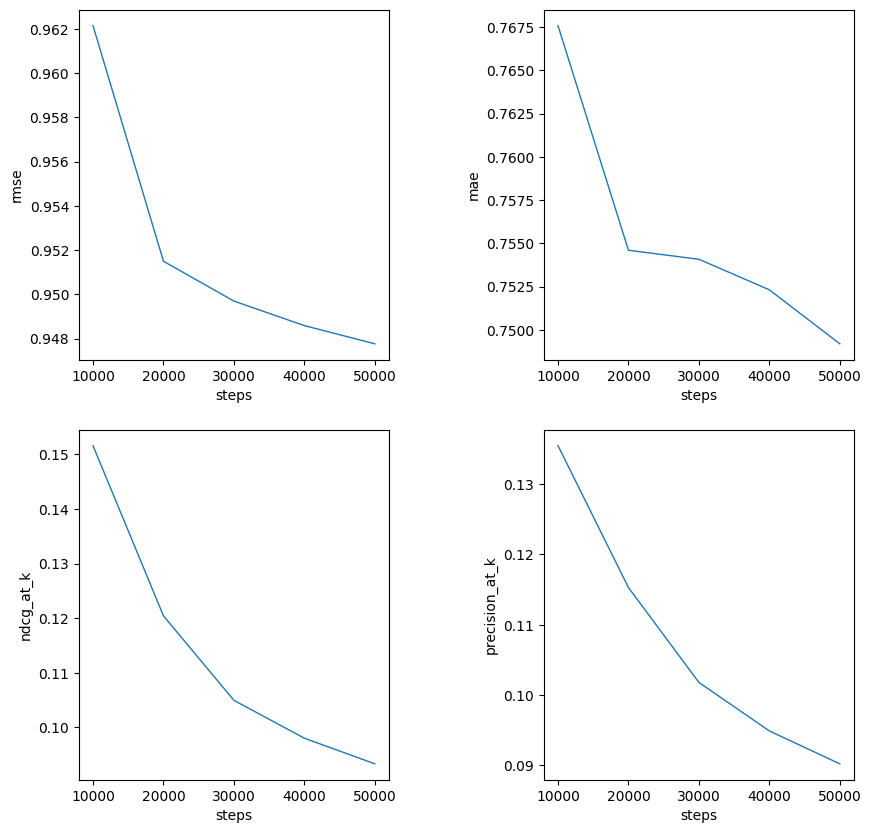

In [13]:
if EVALUATE_WHILE_TRAINING and eval_log:
    for i, (m_name, values) in enumerate(eval_log.items(), 1):
        store_metadata("eval_{}".format(m_name), values)
        x = [save_checkpoints_steps * j for j in range(1, len(values) + 1)]
        plot.line_graph(
            values=list(zip(values, x)),
            labels=m_name,
            x_name="steps",
            y_name=m_name,
            subplot=(math.ceil(len(eval_log) / 2), 2, i),
        )

### 4. Test and Export Model

#### 4.1 Item rating prediction

In [14]:
if len(RATING_METRICS) > 0:
    predictions = predict(
        model,
        test,
        users=wide_columns.get('users', deep_columns.get('users')),
        items=wide_columns.get('items', deep_columns.get('items')),
        item_feat_col=ITEM_FEAT_COL,
    )
    prediction_df = test.drop(RATING_COL, axis=1)
    prediction_df[PREDICT_COL] = predictions

    rating_results = {}
    for m_name in RATING_METRICS:
        result = evaluator.metrics[m_name](test, prediction_df, **cols)
        store_metadata(m_name, result)
        rating_results[m_name] = result
    print(rating_results)

{'rmse': 0.9477648484822748, 'mae': 0.7491909999155998}


#### 4.2 Recommend k items
For top-k recommendation evaluation, we use the ranking pool (all the user-item pairs) we prepared earlier. We remove users' seen items from the pool which is more natural to the movie recommendation scenario.

In [15]:
if len(RANKING_METRICS) > 0:
    predictions = predict(
        model,
        ranking_pool,
        users=wide_columns.get('users', deep_columns.get('users')),
        items=wide_columns.get('items', deep_columns.get('items')),
        item_feat_col=ITEM_FEAT_COL,
    )
    prediction_df = ranking_pool.copy()
    prediction_df[PREDICT_COL] = predictions

    ranking_results = {}
    for m_name in RANKING_METRICS:
        result = evaluator.metrics[m_name](test, prediction_df, **{**cols, 'k': TOP_K})
        store_metadata(m_name, result)
        ranking_results[m_name] = result
    print(ranking_results)

{'ndcg_at_k': 0.09333924630101367, 'precision_at_k': 0.09023354564755841}


#### 4.3 Export Model
Finally, we export the model so that we can load later for re-training, evaluation, and prediction.

In [16]:
os.makedirs(EXPORT_DIR_BASE, exist_ok=True)
export_path = os.path.join(EXPORT_DIR_BASE, "wide_deep_model.pt")
torch.save(model.state_dict(), export_path)
store_metadata('saved_model_dir', export_path)
print("Model exported to", export_path)

Model exported to outputs/model/wide_deep_model.pt
